## Classification de sentiemens dans le  texte 
Naif : "A et B sont independants "
P(A|B) = P(A) B n'as aucun influence sur A
- 1er step : 
P(Y) {P(Y=0),P(Y=1)}
- 2eme step:
Etablir vocabulaire 
["mot",count]
- 3eme step : 
P("texte1"/Y)
- 4eme step: 
P(Y/"texte") = P(Y)*P(T/Y)

In [3]:
# ── Imports ───────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
 
from collections import Counter

from sklearn.metrics            import (accuracy_score, classification_report,
                                        confusion_matrix, ConfusionMatrixDisplay)
 
import warnings
warnings.filterwarnings("ignore")




In [4]:
def Read_txt(data):
    df = pd.read_csv(data, sep='\t', header=None, names=['sentence', 'label'],encoding='utf-8')
    df.dropna(inplace=True)
    df["label"] = df['label'].astype(int)
    return df

print("chargement des données...")
# divisioin des dataset 
test_df = Read_txt("./data/sentiment+labelled+sentences/sentiment labelled sentences/imdb_labelled.txt")
train_df = Read_txt("./data/sentiment+labelled+sentences/sentiment labelled sentences/amazon_cells_labelled.txt")

print(test_df.head(5).to_string(index=False))
print(train_df.head(5).to_string(index=False))

chargement des données...
                                                                                                                                                                                    sentence  label
                                                                                                     A very, very, very slow-moving, aimless movie about a distressed, drifting young man.        0
                                                                                         Not sure who was more lost - the flat characters or the audience, nearly half of whom walked out.        0
Attempting artiness with black & white and clever camera angles, the movie disappointed - became even more ridiculous - as the acting was poor and the plot and lines almost non-existent.        0
                                                                                                                                                Very little music or anything to speak of.    

In [5]:
## Calcul de probabilité de P(y)
count = train_df["label"].value_counts().sort_index()
total = len(train_df)
prob_y = count / total
print("\nProbabilité de P(y):")
print(prob_y)

##repartition des target dans le train 
summary = pd.DataFrame({
    "classe ": ["Y : 0 (negative)", "Y : 1 (positive)" ],
    "Nb_exemple": [count[0], count[1]],
    "Pourcentage": [prob_y[0] * 100, prob_y[1] * 100]
})
print("\nRépartition des classes dans le train:")
print(summary.to_string(index=False))


Probabilité de P(y):
label
0    0.5
1    0.5
Name: count, dtype: float64

Répartition des classes dans le train:
         classe   Nb_exemple  Pourcentage
Y : 0 (negative)         500         50.0
Y : 1 (positive)         500         50.0


## les classe sont bien reparties 


In [6]:
## STEP 2 — Fréquences des mots par classe (from scratch)
import re

def tokenize(phrase):
    """Découpe une phrase en mots alphabétiques en minuscules."""
    return re.findall(r'[a-z]+', phrase.lower())

# Compter chaque mot séparément pour Y=0 et Y=1
freq_neg = Counter()   # fréquences des mots dans les phrases négatives
freq_pos = Counter()   # fréquences des mots dans les phrases positives

for _, row in train_df.iterrows():
    mots = tokenize(row['sentence'])
    if row['label'] == 0:
        freq_neg.update(mots)
    else:
        freq_pos.update(mots)

print('Top 10 mots — Y=0 (Négatif):')
print(freq_neg.most_common(10))
print()
print('Top 10 mots — Y=1 (Positif):')
print(freq_pos.most_common(10))

Top 10 mots — Y=0 (Négatif):
[('the', 280), ('i', 195), ('it', 166), ('and', 122), ('a', 113), ('to', 110), ('this', 103), ('is', 102), ('not', 102), ('phone', 80)]

Top 10 mots — Y=1 (Positif):
[('the', 239), ('and', 189), ('i', 188), ('it', 145), ('is', 141), ('a', 108), ('this', 105), ('great', 94), ('phone', 88), ('to', 87)]


In [7]:
## STEP 3 — P(mot | Y)  :  Vraisemblance from scratch avec lissage Laplace
#
#   P(mot | Y=k) =   count(mot, k) + 1
#                  ─────────────────────────────────
#                  total_mots_k  +  1 × taille_vocab
#
# On travaille en log pour éviter les underflows numériques.

import math

# Vocabulaire = union de tous les mots des deux classes
vocab = set(freq_neg.keys()) | set(freq_pos.keys())
vocab_size  = len(vocab)
total_neg   = sum(freq_neg.values())   # total mots dans les phrases négatives
total_pos   = sum(freq_pos.values())   # total mots dans les phrases positives
alpha       = 1                         # lissage de Laplace

print(f'Taille du vocabulaire : {vocab_size}')
print(f'Total mots Y=0        : {total_neg}')
print(f'Total mots Y=1        : {total_pos}')
print()

# Calcul des log-probabilités pour chaque mot du vocabulaire
log_P_mot_neg = {}   # log P(mot | Y=0)
log_P_mot_pos = {}   # log P(mot | Y=1)

for mot in vocab:
    count_n = freq_neg.get(mot, 0)
    count_p = freq_pos.get(mot, 0)
    log_P_mot_neg[mot] = math.log((count_n + alpha) / (total_neg + alpha * vocab_size))
    log_P_mot_pos[mot] = math.log((count_p + alpha) / (total_pos + alpha * vocab_size))

# Affichage de quelques exemples
exemples = ['good', 'bad', 'great', 'terrible', 'love', 'hate', 'worst', 'best', 'amazing', 'awful']
lignes = []
for mot in exemples:
    if mot in log_P_mot_neg:
        lignes.append({
            'Mot'         : mot,
            'log P(w|Y=0)': round(log_P_mot_neg[mot], 4),
            'log P(w|Y=1)': round(log_P_mot_pos[mot], 4)
        })
print(pd.DataFrame(lignes).to_string(index=False))

Taille du vocabulaire : 1812
Total mots Y=0        : 5375
Total mots Y=1        : 5013

     Mot  log P(w|Y=0)  log P(w|Y=1)
    good       -6.2410       -4.6387
     bad       -6.1720       -8.8283
   great       -7.0883       -4.2745
terrible       -6.4821       -8.8283
    love       -8.8800       -5.7838
    hate       -7.2706       -8.8283
   worst       -6.1720       -8.8283
    best       -7.7814       -5.7373
 amazing       -8.8800       -8.1352
   awful       -7.4937       -8.1352


STEP 4 — Évaluation sur le jeu de test (from scratch)

  Accuracy : 0.7086  (70.86%)

              precision    recall  f1-score   support

 Négatif (0)       0.69      0.73      0.71       362
 Positif (1)       0.73      0.69      0.71       386

    accuracy                           0.71       748
   macro avg       0.71      0.71      0.71       748
weighted avg       0.71      0.71      0.71       748



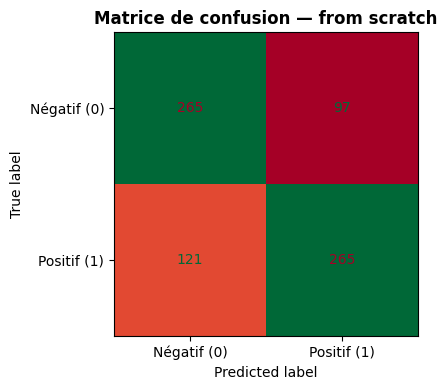

In [8]:
## STEP 4 — P(Y | Texte) = P(Y) * P(Texte | Y)  [from scratch]
#
#   log P(Y=0 | Texte) = log P(Y=0)  +  Σ  log P(mot | Y=0)
#   log P(Y=1 | Texte) = log P(Y=1)  +  Σ  log P(mot | Y=1)
#
#   Prédiction = argmax(score Y=0, score Y=1)

# log-priors déjà calculés au Step 1
log_P_Y0 = math.log(prob_y[0])
log_P_Y1 = math.log(prob_y[1])

# log P(mot inconnu) avec Laplace (count = 0)
log_inconnu_neg = math.log(alpha / (total_neg + alpha * vocab_size))
log_inconnu_pos = math.log(alpha / (total_pos + alpha * vocab_size))

def predict_bayes(phrase):
    """
    Calcule manuellement :
      score(Y=k) = log P(Y=k) + Σ log P(mot | Y=k)
    et retourne la classe gagnante.
    """
    tokens   = tokenize(phrase)

    # On part du prior (Step 1)
    score_Y0 = log_P_Y0
    score_Y1 = log_P_Y1

    for mot in tokens:
        # On ajoute log P(mot | Y=k) pour chaque mot (Step 3)
        score_Y0 += log_P_mot_neg.get(mot, log_inconnu_neg)
        score_Y1 += log_P_mot_pos.get(mot, log_inconnu_pos)

    prediction = 1 if score_Y1 > score_Y0 else 0
    return prediction, score_Y0, score_Y1


# Évaluation sur tout le jeu de test
resultats    = [predict_bayes(p) for p in test_df['sentence']]
y_pred_manuel = [r[0] for r in resultats]

acc = accuracy_score(test_df['label'], y_pred_manuel)
print('=' * 60)
print('STEP 4 — Évaluation sur le jeu de test (from scratch)')
print('=' * 60)
print(f'\n  Accuracy : {acc:.4f}  ({acc*100:.2f}%)')
print()
print(classification_report(test_df['label'], y_pred_manuel,
                             target_names=['Négatif (0)', 'Positif (1)']))

cm  = confusion_matrix(test_df['label'], y_pred_manuel)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Négatif (0)', 'Positif (1)'])
disp.plot(ax=ax, colorbar=False, cmap='RdYlGn')
ax.set_title('Matrice de confusion — from scratch', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
## DEMO — Prédiction manuelle sur de nouvelles phrases
#
#  Formule appliquée mot par mot :
#    score(Y=0) = log P(Y=0) + log P(mot1|Y=0) + log P(mot2|Y=0) + ...
#    score(Y=1) = log P(Y=1) + log P(mot1|Y=1) + log P(mot2|Y=1) + ...
#    Prédiction = argmax(score Y=0, score Y=1)

new_sentences = [
    'This product is absolutely amazing and I love it',
    'Terrible quality, I hate this product',
    'It was okay, nothing special',
    'Best purchase I have ever made',
    'Complete waste of money, very disappointed',
    'Highly recommend, works perfectly',
    'Broke after one day, do not buy',
    'I hate this items',
    'I agree with that product',
    'wasted two hours',
    'you deserve love',
    'you deserve hate',
    'too late',
    'Wow... Loved this place.'
]

lignes = []
for phrase in new_sentences:
    pred, score0, score1 = predict_bayes(phrase)
    lignes.append({
        'Phrase'     : phrase,
        'score Y=0'  : round(score0, 4),
        'score Y=1'  : round(score1, 4),
        'Prédiction' : ' POSITIF' if pred == 1 else ' NÉGATIF'
    })

pd.set_option('display.max_colwidth', 50)
print(pd.DataFrame(lignes).to_string(index=False))

                                          Phrase  score Y=0  score Y=1 Prédiction
This product is absolutely amazing and I love it   -52.2974   -46.4063    POSITIF
           Terrible quality, I hate this product   -33.9635   -36.7660    NÉGATIF
                    It was okay, nothing special   -34.3585   -35.5472    NÉGATIF
                  Best purchase I have ever made   -37.4822   -35.3265    POSITIF
      Complete waste of money, very disappointed   -38.0628   -44.8096    NÉGATIF
               Highly recommend, works perfectly   -32.8811   -24.9687    POSITIF
                 Broke after one day, do not buy   -43.8121   -49.8075    NÉGATIF
                               I hate this items   -23.9882   -26.1014    NÉGATIF
                       I agree with that product   -28.8965   -28.3508    POSITIF
                                wasted two hours   -22.4280   -24.5391    NÉGATIF
                                you deserve love   -23.4620   -20.9148    POSITIF
                